In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM.</p>
<hr/>

In [2]:
import importlib
import warnings
import numpy as np
from sklearn import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2

In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [4]:
warnings.filterwarnings("ignore", category=ConvergenceWarning, append=True)

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [5]:
gamma_values = np.logspace(1, 1.8, 6)

# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = [
    {  # custom
        "model__estimator__kernel": [cr.CustomRBFKernel(g) for g in gamma_values],
        "model__estimator__C": [1e-2, 1e0, 1e2, 1e4],
        "model__estimator__gamma": [1e-4, 1e-2, 1e0],
        "model__estimator__epsilon": [0.01, 0.1, 0.5],
    },
    # {  # linear
    #     "model__estimator__kernel": ["linear"],
    #     "model__estimator__C": [0.1, 1, 10, 100],
    #     "model__estimator__epsilon": [0.01, 0.05, 0.1, 0.2],
    # },
    {  # RBF
        "model__estimator__kernel": ["rbf"],
        "model__estimator__C": [3, 10, 30, 100],
        "model__estimator__gamma": ["scale", 0.1, 0.3, 1, 3],
        "model__estimator__epsilon": [0.1, 0.4, 0.8],
    },
    {  # Polynomial
        "model__estimator__kernel": ["poly"],
        "model__estimator__C": [0.1, 1, 10],
        "model__estimator__gamma": ["scale", 0.03, 0.1],
        "model__estimator__epsilon": [0.1, 0.4],
        "model__estimator__degree": [2, 3],
        "model__estimator__coef0": [0, 1],
    }
]

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(SVR()))
])

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,max),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------

# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [8]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    error_score="raise",
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gs.fit(X_tr, y_tr)

best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)


cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 348  splits: 5
Best params: {'model__estimator__C': 30, 'model__estimator__epsilon': 0.1, 'model__estimator__gamma': 3, 'model__estimator__kernel': 'rbf'}
Best score: -16.88153338907147
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', MultiOutputRegressor(estimator=SVR(C=30, gamma=3)))])


<h3>Learning Curve</h3>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

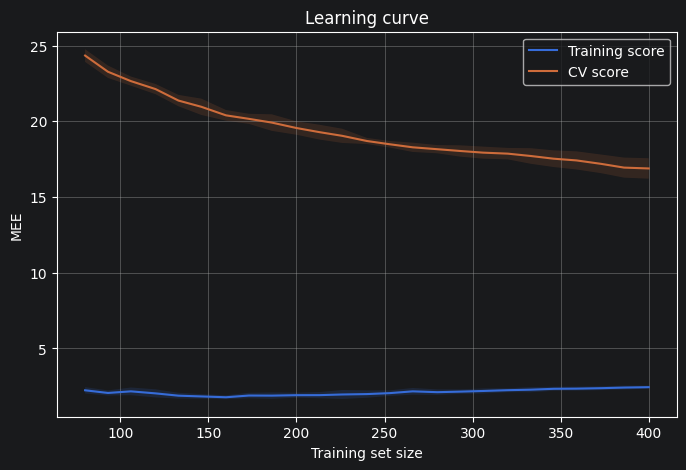

In [9]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [10]:
non_nested_runner = cr.SklearnRegressorRunner(gs)
non_nested_kf_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.3076
Validation MSE       | 90.5739
Validation MAE       | 7.1356
Validation RMSE      | 9.5170
Validation R2        | 0.6964
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.9211
Validation MSE       | 95.6686
Validation MAE       | 7.5098
Validation RMSE      | 9.7810
Validation R2        | 0.6780
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.3351
Validation MSE       | 86.2467
Validation MAE       | 7.1494
Validation RMSE    

In [11]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -16.8815 ± 0.6750
Best CV func score: 16.8815 ± 0.6750


<h3>Nested Cross Validation</h3>

In [12]:
importlib.reload(cr)

outer_cv = outer_cv
inner_cv = cr.common_fold_strategy(n_split=3)

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
with warnings.catch_warnings():
    nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 348  splits: 3
Best params: {'model__estimator__C': 30, 'model__estimator__epsilon': 0.1, 'model__estimator__gamma': 3, 'model__estimator__kernel': 'rbf'}
Best score: -18.167466206361997
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', MultiOutputRegressor(estimator=SVR(C=30, gamma=3)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.3076
Validation MSE       | 90.5739
Validation MAE       | 7.1356
Validation RMSE      | 9.5170
Validation R2        | 0.6964
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 348  splits: 3
Best params: {'model__estimator__C': 100, 'model__estimator__epsilon': 0.1, 'model__es

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

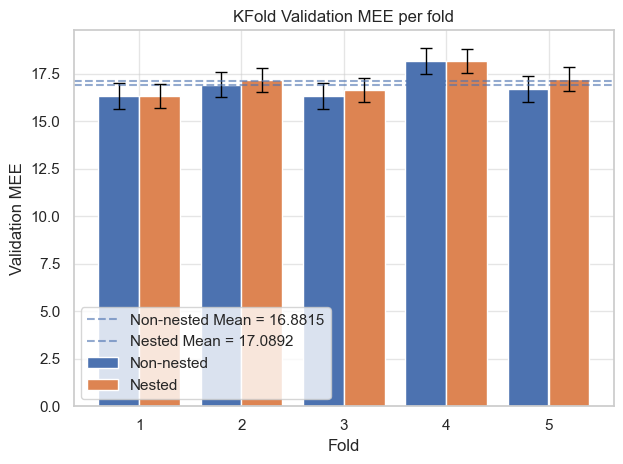

MEE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,2.464688,16.307557,13.842869
2,0.293514,17.178737,16.885223
3,0.245105,16.609982,16.364877
4,2.411331,18.151435,15.740105
5,0.236017,17.198421,16.962404
MEAN,1.130131,17.089227,15.959096
STD,1.068190,0.630699,1.145021


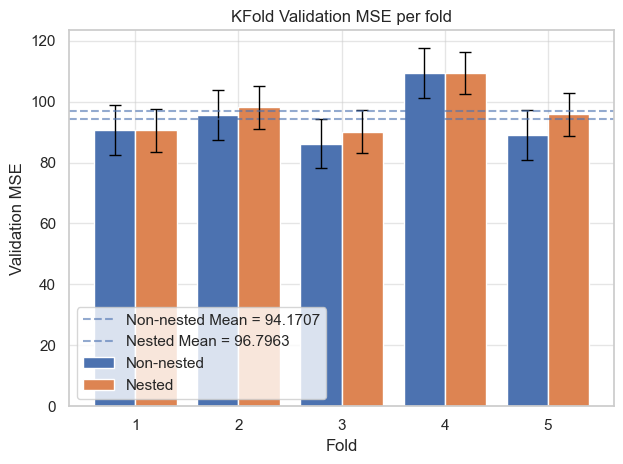

MSE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,7.136714,90.573878,83.437164
2,0.269422,98.081460,97.812038
3,0.146920,90.197534,90.050614
4,7.856787,109.333511,101.476724
5,0.080234,95.794877,95.714642
MEAN,3.098015,96.796252,93.698237
STD,3.599275,6.958425,6.325960


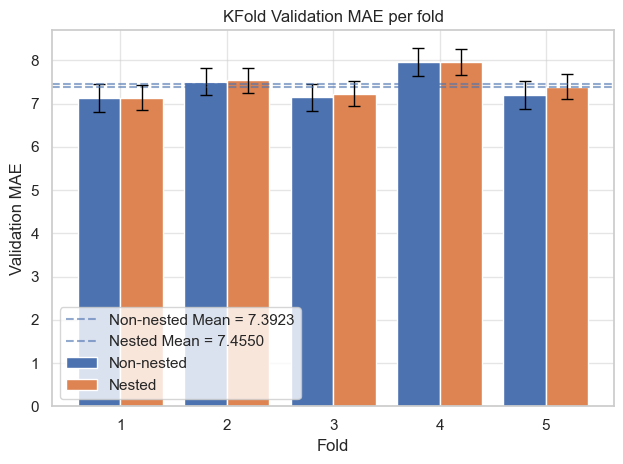

MAE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.852007,7.135642,6.283635
2,0.123535,7.545399,7.421863
3,0.111350,7.231370,7.120020
4,0.796401,7.964588,7.168187
5,0.108931,7.397833,7.288902
MEAN,0.398445,7.454966,7.056521
STD,0.348110,0.290902,0.400332


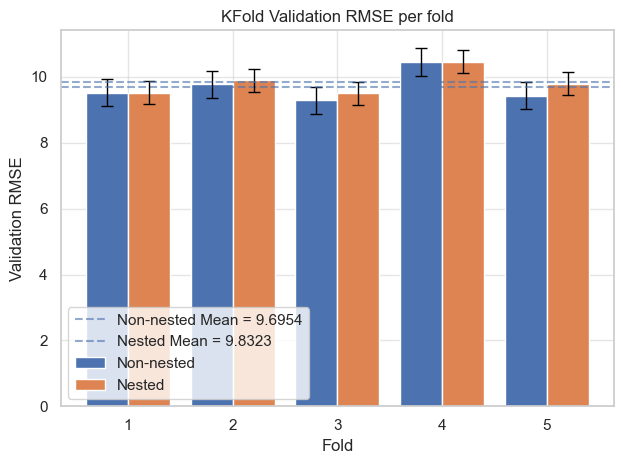

RMSE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,2.671463,9.517031,6.845568
2,0.519059,9.903608,9.384550
3,0.383301,9.497238,9.113937
4,2.802996,10.456267,7.653270
5,0.283256,9.787486,9.504229
MEAN,1.332015,9.832326,8.500311
STD,1.150544,0.348737,1.060370


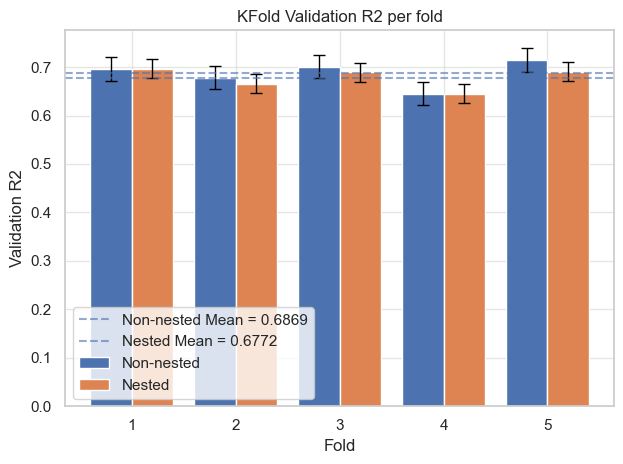

R2 TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.977011,0.696368,-0.280643
2,0.998793,0.665298,-0.333496
3,0.999324,0.689413,-0.309910
4,0.973949,0.644795,-0.329154
5,0.999620,0.690177,-0.309443
MEAN,0.989739,0.677210,-0.312529
STD,0.011686,0.019374,0.018703


In [13]:
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_kf_result, "Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric.upper()} TR vs VL from KFold Nested results")
    display(cr.kfold_summary(nested_result, use=metric))

<h3>Bootstrap Variance</h3>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [14]:
importlib.reload(cr)
bootstrap_samples = 100
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}

with warnings.catch_warnings():
    bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_dict,bootstrap_params=bootstrap_params)


In [15]:
importlib.reload(cr)
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MEE,17.70,0.69,3.89
1,MSE,103.82,8.25,7.95
2,R2,0.66,0.02,3.61
3,RMSE,10.18,0.40,3.97
4,MAE,7.73,0.30,3.93


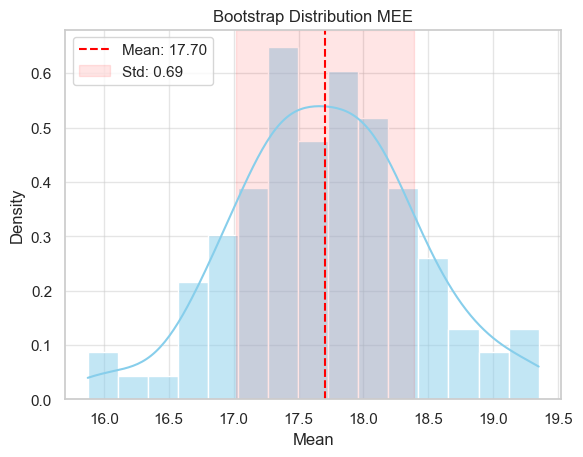

In [16]:
cr.plot_bootstrap_distribution([metric[default_metric] for metric in bootstrap_scores], title=f"Bootstrap Distribution {default_metric.upper()}")

<h2>Test predictions</h2>
<hr/>

In [17]:

fitted_model = non_nested_runner.fitted_model(X_tr, y_tr)
y_pred = non_nested_runner.predict(fitted_model, X_ts)

In [18]:
print(y_pred)

[[ -2.52879385  -0.23988814   3.83689715  -8.92675335]
 [ -5.66997362 -17.51657583 -45.46179823   3.75651669]
 [ -1.31505051  -0.73675608  -3.57082018   3.3981184 ]
 ...
 [ -7.75026516  15.67453757  18.79148312  -9.19390964]
 [  8.46137338  14.56603736 -29.33323635   6.62351261]
 [ -0.338698     1.57513751   3.03664994  -3.42071695]]


<hr/>